# 3. An Introductory Example

### Simple piece of code

In [2]:
import numpy as np
a = np.linspace(-np.pi, np.pi, 100)
b = np.cos(a)
c = np.sin(a)
d = b@c
print(d)

4.510281037539698e-16


### White noise plot

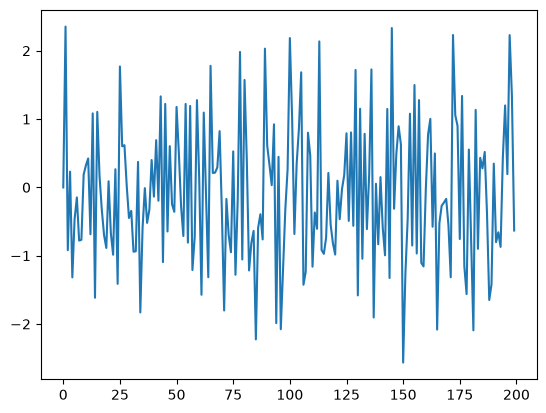

In [6]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()
X = rng.standard_normal(200)
plt.plot(X)
plt.show()


### White noise plot (alt.)

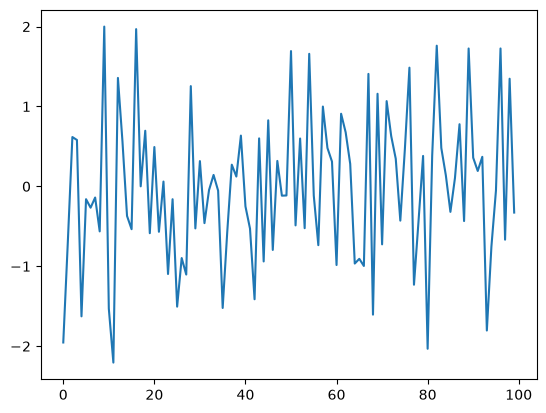

In [7]:
ts_lenght = 100
X = []
for i in range(ts_lenght):
    x = rng.standard_normal()
    X.append(x)

plt.plot(X)
plt.show()

### For-While loops practice

In [2]:
numbers = [1,2,3,4]
doubles = []
for x in numbers:
    doubles.append(x*2)
print(doubles)    

[2, 4, 6, 8]


In [10]:
numbers = [1,2,3,4]
i=0
for x in numbers:
    numbers[i]=x*2
    i=i+1
print(numbers)    

[2, 4, 6, 8]


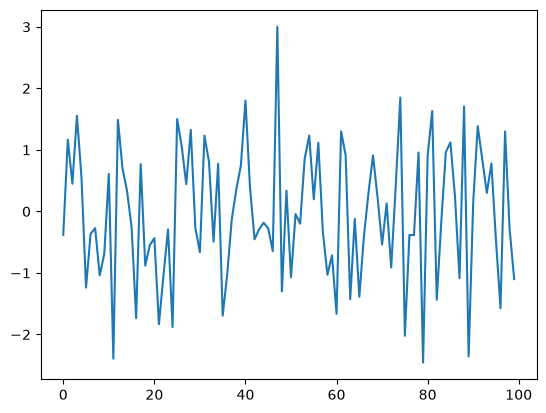

In [7]:
ts_lenght = 100
X = []
i=0
while i<ts_lenght:
    x = rng.standard_normal()
    X.append(x)
    i=i+1
plt.plot(X)
plt.show()    


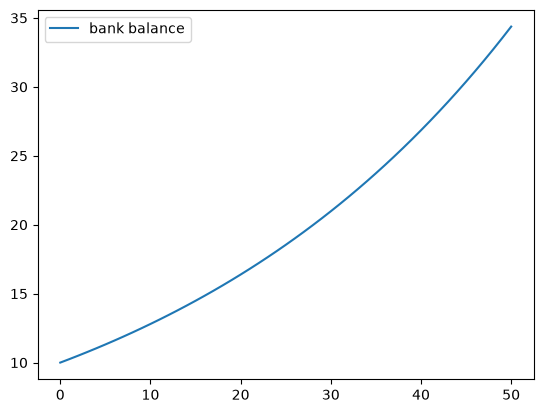

In [12]:
r=0.025
T=50
b=np.empty(T+1)
b[0]=10

for t in range(T):
    b[t+1]=(1+r)*b[t]
plt.plot(b, label='bank balance')
plt.legend()
plt.show()    

<function matplotlib.pyplot.show(close=None, block=None)>

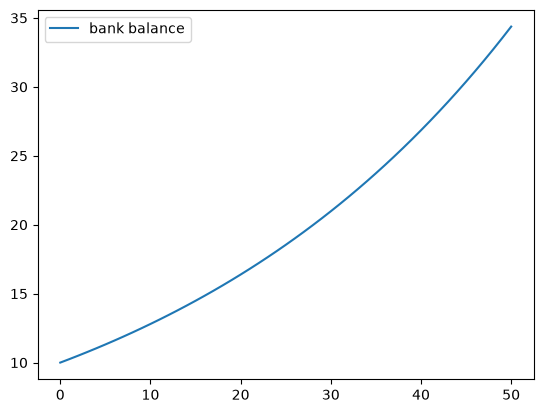

In [18]:
r=0.025
T=50
b=[0]*(T+1)
b[0]=10
i=0

for x in range(T):
    b[i+1]=b[i]*(1+r)
    i=i+1

plt.plot(b, label='bank balance')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

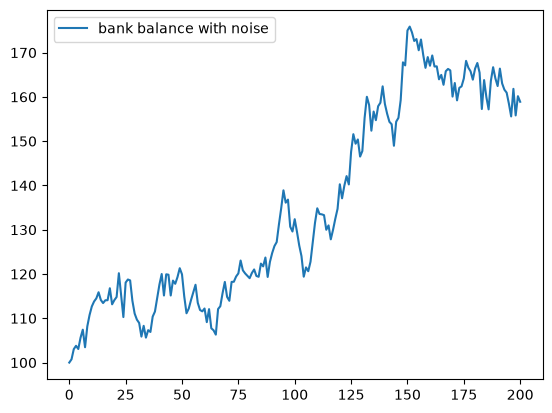

In [34]:
r=0.025
T=200
b=[0]*(T+1)
b[0]=100
i=0

for x in range(T):
    b[i+1]=b[i]*(1+r*rng.standard_normal())
    i=i+1

plt.plot(b, label='bank balance with noise')
plt.legend()
plt.show

## Exercises

### Exercise 3.1

Plot an autoregressive process of order 1 with parameters $\alpha$=0.9 and T=200

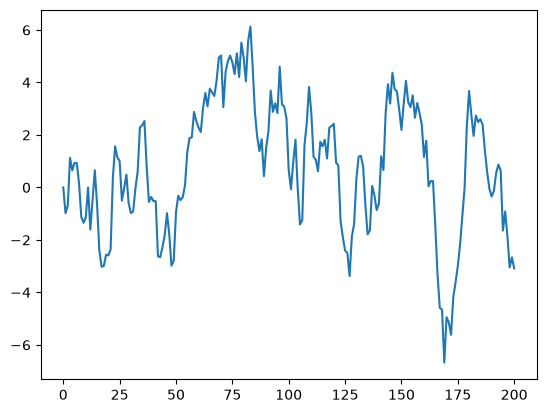

In [37]:
T=200
alpha=0.9
x=np.empty(T+1)
x[0]=0

for i in range (T):
    x[i+1]=alpha*x[i]+rng.standard_normal()

plt.plot(x)
plt.show()


### Exercise 3.2

Simulate three plots with $\alpha$=0, 0.8, 0.98 and with the correct legend.

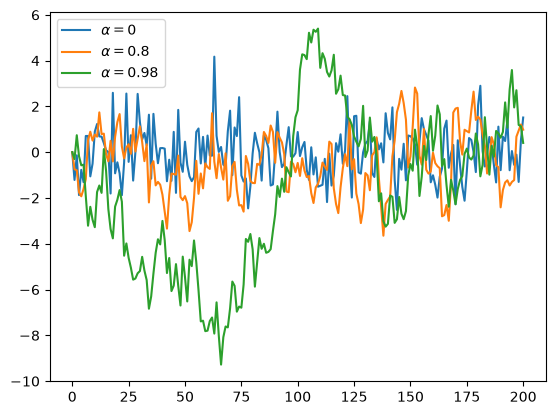

In [53]:
T=200
Alpha=[0, 0.8, 0.98]
x=np.empty(T+1)
x[0]=0

for alpha in Alpha:
    for i in range (T):
        x[i+1]=alpha*x[i]+rng.standard_normal()
    plt.plot(x, label=f'$\\alpha={alpha}$')
plt.legend()
plt.show()

### Exercise 3.3

Simulate an autoregressive process of order 1 with absolute value. Same parameters as before.

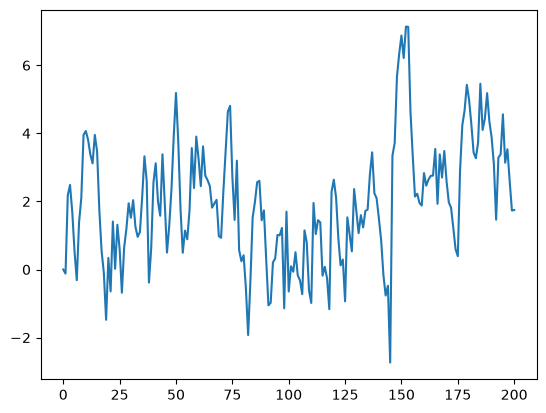

In [54]:
T=200
alpha=0.9
x=np.empty(T+1)
x[0]=0

for i in range (T):
    x[i+1]=alpha*np.absolute(x[i])+rng.standard_normal()

plt.plot(x)
plt.show()


### Exercise 3.4

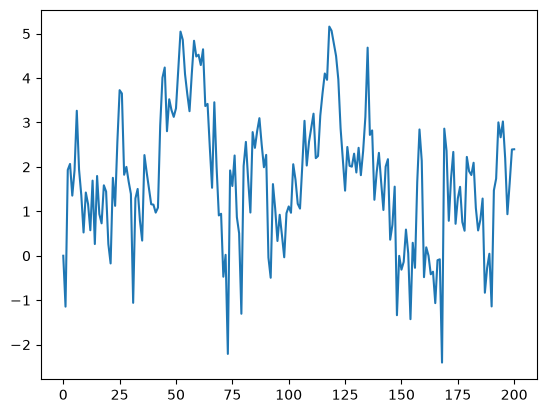

In [56]:
T=200
alpha=0.9
x=np.empty(T+1)
x[0]=0

for i in range (T):
    if x[i]>=0:
        x[i+1]=alpha*x[i]+rng.standard_normal()
    else: 
        x[i+1]=alpha*(-1)*x[i]+rng.standard_normal()

plt.plot(x)
plt.show()


### Exercise 3.5

Compute and approximation to $\pi$ using Monte Carlo

In [98]:
N=100000
c=0
s=0

for t in range(N):
    n=np.random.rand(2)
    r=np.sqrt(np.dot(n, n))
    if r <=1:
        c=c+1

pi=(c/N)*4  
print(pi)


3.14436


# 4. Functions

## Basics

In [3]:
def new_abs(x):
    if x<0:
        abs=-x
    else:
        abs=x
    return abs     

print(new_abs(-3), new_abs(3))

3 3


In [14]:
import numpy as np
def f(x, y, z):
    n=np.sqrt(x**2+y**2+z**2)
    return n

print(f(1, 2, 3))    

3.7416573867739413


## Anonymous function

In [15]:
f=lambda x: x**3
print(f(2))

8


In [17]:
from scipy.integrate import quad
f=lambda x: x**3
i=quad(f,0,2)
print(i)

(4.0, 4.440892098500626e-14)


## Applications

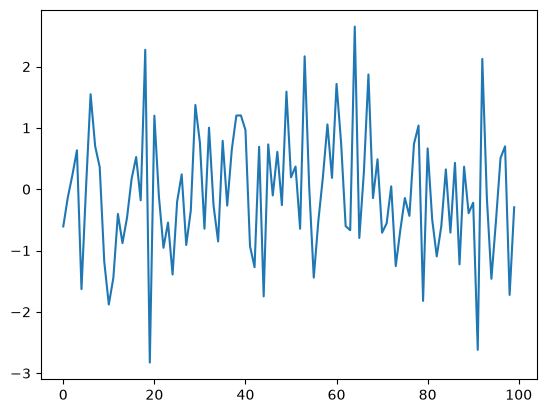

In [26]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()

def wn_vis(N):
    N=int(input("Set N:"))
    n=[]
    for i in range(N):
        x=rng.standard_normal()
        n.append(x)
    return(n)

data=wn_vis(100)
plt.plot(data)
plt.show()


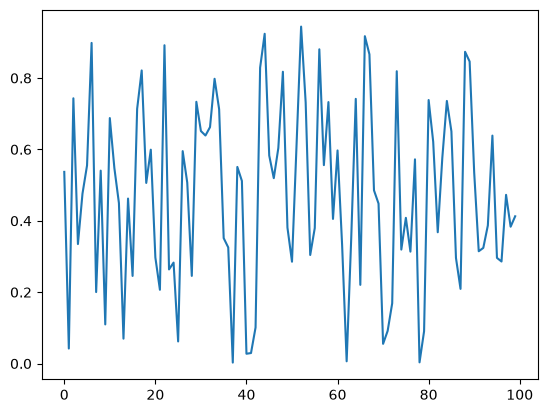

In [35]:
def data_generator (N, d_type):
    n=[]
    for i in range(N):
            if d_type == 'U':
                x=rng.uniform(0,1)
            else:
                x=rng.standard_normal()
            n.append(x)
    return(n)

data=data_generator (100, 'U')
plt.plot(data)
plt.show()

## Recursive functions

In [37]:
def x_loop(t):
    x=1
    for i in range(t):
        x=2*x
    return x    

## Exercises

### Exercise 4.1

In [ ]:
Write a factorial function.

In [58]:
def fac(n):
    i=0
    m=1
    while i<(n):
        m=m*(n-i)
        i=i+1
    return(m)
print(fac(4))        

24


### Exercise 4.2

Write the function of a negative-binomial random variable Y, where n is the number of successes and p is the probability of a success.

In [102]:
def bin(n,p):
    l=[1,2,3]
    s=0
    d=0
    while s<n:
        x=rng.standard_normal()
        d=d+1
        if x>(1-p):
            s=s+1
    return(d)
print(bin(10,0.3))    

27


### Exercise 4.3

Build a function which tosses a coin 10 times and output 1 if head comes up at least 4 times in a row.

In [487]:
def coin(n):
    h=0    
    for t in range(n):
        x=rng.standard_normal()
        if x>0:
            h=h+1
            if h==4:
                return(1)
        else:
            h=0                    
    return(0)
print(coin(10))                    

0


### Exercise 4.4

Build a function that writes the Fibonacci sequence up untill the n element.

In [493]:
def fib(n):
    x=0
    y=1
    z=y+x
    s=[x,y,z]
    for i in range(n):
        x=y
        y=z
        z=y+x
        s.append(z)
    return(s)
print(fib(10))        


[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144]


# 5. Python Essentials

## Exercises

### Exercise 5.1

Part 1: Given two numeric lists or tuples x_vals and y_vals of equal length, compute their inner product using zip().

Part 2: In one line, count the number of even numbers in 0,…,99.

Part 3: Given pairs = ((2, 5), (4, 2), (9, 8), (12, 10)), count the number of pairs (a, b) such that both a and b are even.

In [2]:
x=[1,2,3]
y=[0,1,2]
s=[]
for i,j in zip(x,y):
    s.append(i*j)
print(sum(s))


8


In [4]:
e=[]
for i in range(99):
    if i%2==0:
        e.append(i)
print(len(e))        

50


In [14]:
s=((2, 5), (4, 2), (9, 8), (12, 10))
e=0
for i in s:
    if (i[0]+i[1])%2==0:
        e=e+1
print(e)

2


### Exercise 5.2

Consider the general expression of a polynomial. 
Write a function p such that p(x, coeff) that computes the value of the polynomial expression given a point x and a list of coefficients.
Try to use enumerate() in your loop.

In [17]:
def p(x, coeff):
    s=[]
    for i in range(len(coeff)):
        s.append(coeff[i]*x**i)
    return(sum(s))
print(p(2,(1,2,3,4)))        


49


### Exercise 5.3

Write a function that takes a string as an argument and returns the number of capital letters in the string.

In [51]:
def capital(x):
    t=0
    for i in range(len(x)):
        y=x[i]
        if y==x[i].upper():
            t=t+1
    return(t)
print(capital("HEllO"))            
            

3


### Exercise 5.4

Write a function that takes two sequences seq_a and seq_b as arguments and returns True if every element in seq_a is also an element of seq_b, else False.

-  By “sequence” we mean a list, a tuple or a string.

-  Do the exercise without using sets and set methods.


In [64]:
def seq(x,y):
    for i,j in zip(x,y):
        if i==j:
            v=True
        else:
            v=False
    return(v)    
print(seq([1,3],[1,3]))    
    

True


### Exercise 5.5

In particular, without using any imports, write a function linapprox that takes as arguments

-  A function f mapping some interval [a,b] into R
-  Two scalars a and b providing the limits of this interval.
-  An integer n determining the number of grid points.
-  A number x satisfying a <= x <= b.

and returns the piecewise linear interpolation of f at x, based on n evenly spaced grid points a = point[0] < point[1] < ... < point[n-1] = b.

In [ ]:
def linapprox(n):
    y=x**3
    l=[]
    for i in range(n):
        l1.append(i)
    for j in range(n):
        l2



# 8. OOP II: Building Classes

## Classes Basics

### Consumers

In [3]:
class Consumer:
    def __init__(self,earn,spend):
        self.earn=earn
        self.spend=spend

c1=Consumer(100,20)
c2=Consumer(120,30)  
print(c1, c1.earn, c1.spend)
print(c2, c2.earn, c2.spend)      

<__main__.Consumer object at 0x7fc2b2f338c0> 100 20
<__main__.Consumer object at 0x7fc2b2ff2d50> 120 30


In [ ]:
class Consumer:

    def __init__(self, w, x, y):
        self.w = w
        self.x = x
        self.y = y
        self.budget = w + x
        self.new_budget = None

    def spend(self):
        if self.y < self.budget:
            self.new_budget = self.budget - self.y
        else:
            print('Unfeasible Consumption')


c1 = Consumer(100, 20, 30)
c2 = Consumer(120, 30, 160)

c1.spend()
c2.spend()

print(c1.w, c1.x, c1.y, c1.budget, c1.new_budget)
print(c2.w, c2.x, c2.y, c2.budget, c2.new_budget)

Unfeasible Consumption
100 20 30 120 90
120 30 160 150 None


### Solow Growth Model

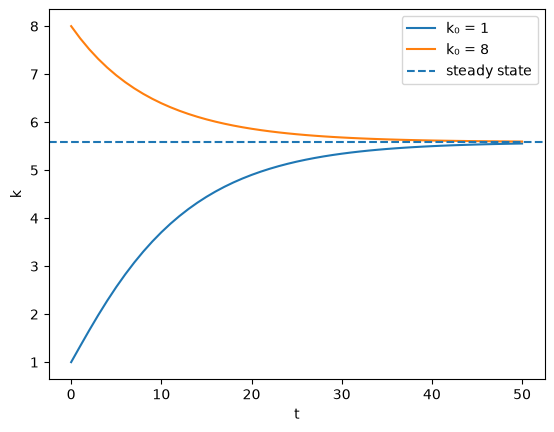

5.5843115041821845


In [ ]:
import matplotlib.pyplot as plt

class Solow:
    def __init__(self,n=0.05,s=0.25,delta=0.1,alpha=0.3,z=2,k=1,T=10):
        self.n=n
        self.s=s
        self.delta=delta
        self.alpha=alpha
        self.z=z
        self.k=k
        self.T=T
        self.l=[(0,k)]

    def h(self):
        for t in range(1, self.T+1):
            self.newk=(self.s*self.z*self.k**self.alpha+(1-self.delta)*self.k)/(1+self.n)
            self.k=self.newk
            self.l.append((t,self.k))
        return(self.l)

    def steady_state(self):
        """Compute the steady state value of capital."""

        n, s, delta, alpha, z = self.n, self.s, self.delta, self.alpha, self.z

        return ((s * z) / (n + delta))**(1 / (1 - alpha))    

k1=Solow(T=50)
k2=Solow(k=8,T=50)

seq1 = k1.h()
seq2 = k2.h()

# Plot k(t)
plt.plot([t for t, k in seq1],
         [k for t, k in seq1],
         label='k₀ = 1')

plt.plot([t for t, k in seq2],
         [k for t, k in seq2],
         label='k₀ = 8')

# Plot steady state
k_star = k1.steady_state()
plt.axhline(k_star, linestyle='--', label='steady state')

plt.xlabel('t')
plt.ylabel('k')
plt.legend()
plt.show()


